In [41]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

In [42]:
rng = np.random.default_rng(seed=123)

def generate_matrix(d, block_size, lam = 0):
    J = lam * np.eye(d) + np.diag([1]*block_size + [0]*(d-block_size-1), k=1)
    S = np.random.rand(d,d)
    X = S @ J @ np.linalg.inv(S)
    return X

Generowanie danych treningowych: 
- J - blok Jordana, gdzie `lam` oznacza wartości na przekątnej, a `block_size` oznacza liczbę "1" nad przekątną, np. dla `lam = 0`, `block_size = 3`: $J = \begin{bmatrix}
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 \\
\end{bmatrix}$. Używanie innych wartości własnych niż 0 nie wpływa na rezultaty. 
- S - losowa macierz przejścia
- do treningu idzie macierz $ X = SJS^{-1}$
- używałem macierzy $ 5 \times 5$. 
- dane składały się ze 100 000 macierzy, po 20 000 z każdej kategorii. 20% danych jest danymi testowymi. 20% z danych treningowych wydzielono na "valid set" do oceny postępu uczenia sieci neuronowej.

In [43]:
d = 5   # matrix dimension
dataset_size = 20000    # number of matrices of each class in the dataset

X = np.ndarray(shape=(dataset_size * d, d, d))
y = []

for block_size in range(d):
    for i in range(dataset_size):
        X[i + block_size * dataset_size] = generate_matrix(d, block_size)
    y += [block_size] * dataset_size

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

X_train = X_train.astype(np.float32)
y_train = np.array(y_train)


In [45]:
model1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(d, d)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(d)
])

model1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=3,            
    restore_best_weights=True
)

model1.fit(
    X_train, y_train,
    epochs=50, 
    validation_split=0.2,   
    callbacks=[early_stop]
)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4482 - loss: 1.7751 - val_accuracy: 0.5137 - val_loss: 1.1079
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5238 - loss: 1.1516 - val_accuracy: 0.5324 - val_loss: 0.9995
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5352 - loss: 1.2295 - val_accuracy: 0.5423 - val_loss: 0.9811
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5384 - loss: 2.3397 - val_accuracy: 0.5534 - val_loss: 0.9480
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5568 - loss: 0.9970 - val_accuracy: 0.5611 - val_loss: 0.9765
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5612 - loss: 1.0356 - val_accuracy: 0.5668 - val_loss: 0.9299
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5794 - loss: 0.9217 - val_accuracy: 0.5896 - val_loss: 0.9550
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5884 - loss: 0.8907 - 

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step


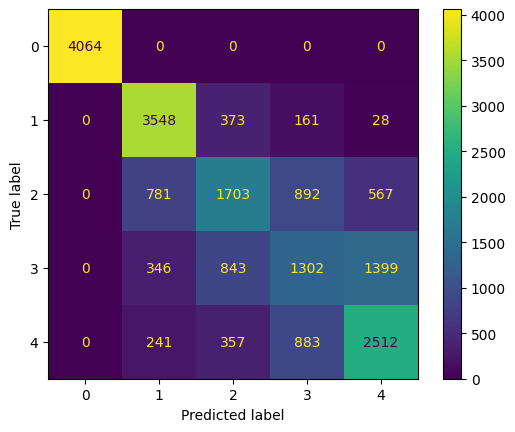

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_predicted = model1.predict(X_test)
y_predicted = np.argmax(y_predicted, axis=1)

cm = confusion_matrix(y_test, y_predicted)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Label = liczba "1" nad przekątną w bloku Jordana. 

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4064
           1       0.72      0.86      0.79      4110
           2       0.52      0.43      0.47      3943
           3       0.40      0.33      0.37      3890
           4       0.56      0.63      0.59      3993

    accuracy                           0.66     20000
   macro avg       0.64      0.65      0.64     20000
weighted avg       0.64      0.66      0.65     20000



Sieć neuronowa bardzo dobrze radzi sobie z rozpoznawaniem macierzy diagonalizowalnych i niediagonalizowalnych. Największy kłopot ma z odróżnianiem wielkości klatek wymiaru >= 2. 